# Распознавание рукописных цифр нейронной сетью с плотными слоями

Практическое занятие №3

Здесь создается и обучается нейронная сеть для распознавания цифр, изображенных на картинках. То есть на вход нейросети будет приходить картинка с числом, а на выходе вы получите само число.

In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

Для начала добавьте в проект все необходимые модули:
* `mnist` – для загрузки набора данных, который вы используете при обучении нейронной сети;
* `sequential` – базовый модуль для создания нейронной сети;
* `Dense` – линейный (полносвязный) слой. Из таких слоев будет создана ваша нейросеть;
* `Adam` – оптимизатор, который вы используете для обучения;
* `utils` – модуль, который содержит некоторые полезные инструменты;
* `image` и `Image` – инструменты для работы с картинками;
* `pylab` и `plt` – с помощью этих модулей вы нарисуете графики.

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


###Загружаем набор данных с рукописными цифрами

Чтобы чему-то научить нейронную сеть, понадобится набор данных для задачи, которую требуется собираетесь решать. В данной задаче это набор картинок, на которых изображены различные цифры. Следующей строкой кода скачиваются эти данные:
* `x_train_org`, `y_train_org` – изображения для обучения нейронной сети.
* `x_test_org`, `y_test_org` – изображения для тестирования нейронной сети.

In [4]:
# В Keras встроены средства работы с популярными наборами данных
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###Вывод размерностей данных базы Mnist

Сейчас те самые картинки, с помощью которых обучается нейронная сеть, представляют из себя матрицы чисел, где каждое число – это значение пикселя (от 0 до 255). Таких изображений в тренировочном наборе данных 60000, и их размеры 28 на 28. Поэтому размерности массива с данными выглядят вот так:

In [5]:
print(x_train_org.shape)
print(x_test_org.shape)

(60000, 28, 28)
(10000, 28, 28)


Если же вы взглянете на массив `y_train_org`, который содержит в себе метки для картинок (то есть значение искомых чисел, изображенных на картинках), то увидите, что этой картинке соответствует значение, например 0:

In [6]:
print(y_train_org.shape)
print(y_test_org.shape)

(60000,)
(10000,)


###Вывод примера числа

Выберите из массива x_train_org какую-нибудь матрицу чисел и отрисуйте ее, чтобы убедиться, что данные действительно представляют собой картинки с числами:

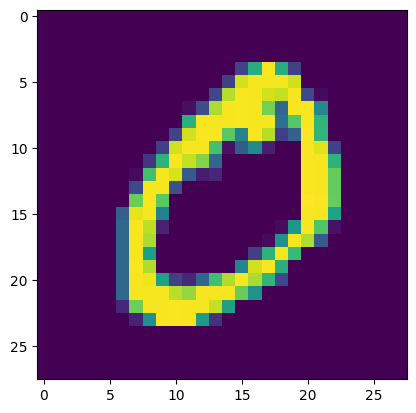

0


In [14]:
n = 1
img = x_train_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_train_org[n])

Сейчас данные имеют сложную структуру, где каждая картинка представляет собой двумерный массив данных.

Но для обучения нейронной сети необходимо преобразовать изображение в более простой вид – в одномерную последовательность чисел.

Это выполняется с помощью метода `.reshape`:

In [15]:
x_train = x_train_org.reshape(60000, 784)
x_test = x_test_org.reshape(10000, 784)

Теперь каждая картинка представлена в наборе данных последовательностью из 784 чисел (28*28).

Как известно, чтобы нейронной сети было легче учиться, необходимо привести входные данные к некоему стандартному виду. В задаче числа, которые описывают картинку (те самые 784 числа), должны находиться в диапазоне от 0 до 1, хотя сейчас это значения от 0 до 255, так как они описывают интенсивность каждого пикселя. Поделив все эти значения на 255, вы нормализуете ваши данные:

In [16]:
# Векторизованные операции
# Применяются к каждому элементу массива отдельно
x_train = x_train.astype('float32') # преобразовываем x_train в тип float (цифры с плавающей точкой)
x_train = x_train / 255 # делим на 255, чтобы диапазон был от 0 до 1

x_test = x_test.astype('float32')
x_test = x_test / 255

Также нужно провести некоторые преобразования и с метками классов, то есть с теми числами, которые отвечают на вопрос «Что же изображено на картинке?».

Для этого нужно привести все метки в one hot encoding формат.

Это значит, что каждое число будет представлять собой последовательность значений 0 или 1. Последовательность будет длиной 10, потому что всего существует 10 цифр, которые сеть будет распознавать (от 0 до 9). В этой последовательности везде стоят нули, кроме позиции самой метки.
* Если ответ равен 5, то one hot encoding представление будет:

      [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]

* А, например, для класса 3:

      [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]


In [17]:
y_train = utils.to_categorical(y_train_org, 10)
y_test = utils.to_categorical(y_test_org, 10)

In [18]:
n=1
print(y_train[n])

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


**Создаем последовательную модель**

Вначале создается объект нейронной сети с помощью класса Sequential:

    model = Sequential()

Сейчас это пустая нейронная сеть, не содержащая в себе никаких слоев и нейронов. В нее нужно добавить несколько слоев нейронов, идущих друг за другом, последовательно:

    model.add(Dense(800, activation="relu"))
    
В данном случае 800 – это количество нейронов в слое, а 'relu' – функция активации, которая будет применяться к данным после выхода из данного слоя.

In [19]:
model = Sequential()
# Входной полносвязный слой, 800 нейронов, 784 входа в каждый нейрон
model.add(Dense(800, input_dim=784, activation="relu"))
# Выходной полносвязный слой, 10 нейронов (по количеству рукописных цифр)
model.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


###Компилируем сеть

В целом, сеть уже создана. Теперь нужно подготовить ее к обучению (скомпилировать) и запустить это обучение.

Следующей строкой кода компилируется модель:

    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

В метод `compile` вы передаете функцию ошибки (`categorical_crossentropy`), оптимизатор нейронной сети (`adam`) и метрики, которые будут подсчитываться в процессе обучения нейросети (`["accuracy"]`).


In [20]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 800)            │       628,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         8,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 636,010 (2.43 MB)

 Trainable params: 636,010 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

None


Метод `summary` выводит на экран структуру вашей нейронной сети: то как она выглядит изнутри:

###Обучаем нейронную сеть

Одной строчкой кода запускается обучение нейронной сети и есть возможность наблюдать за процессом.

Для этого вызовите метод `fit` и передайте ему данные для обучения `(x_train, y_train)`:
    model.fit(x_train, y_train, batch_size=200, epochs=2, verbose=1)

`batch_size` – параметр, который указывает нейросети на то, сколько картинок она будет обрабатывать за один раз.

`epochs` – это количество циклов обучения, то есть сколько раз нейронная сеть просмотрит все ваши данные и обучится на них.

In [21]:
#fit - функция обучения нейронной сети
#x_train, y_train - обучающая выборка, входные и выходные данные
#batch_size - размер батча, количество примеров, которое обрабатывает нейронка перед одним изменением весов
#epochs - количество эпох, когда нейронка обучается на всех примерах выборки
#verbose - 0 - не визуализировать ход обучения, 1 - визуализировать
model.fit(x_train, y_train, batch_size=200, epochs=2,  verbose=1)

Epoch 1/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9210 - loss: 0.2799
Epoch 2/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9666 - loss: 0.1136


Представлен процесс обучения нейронной сети. После каждого цикла обучения вы можете видеть среднее значение ошибки. Обратите внимание, что практически каждую эпоху значение метрики точности (accuracy) увеличивается. Это означает, что ваша нейронная сеть с каждым разом делает все более точные предсказания!

###Запускаем распознавание

In [22]:
# Оцениваем качество обучения сети на тестовых данных
scores = model.evaluate(x_test, y_test, verbose=0)
print("Точность работы на тестовых данных: %.2f%%" % (scores[1]*100))

Точность работы на тестовых данных: 97.19%


Чтобы сеть выдала ответ, нужно вызвать метод predict и передать в него данные для распознавания:

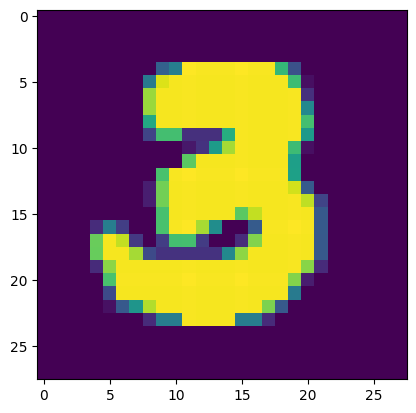

3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[6.7037394e-07 5.4161267e-09 1.3150733e-03 9.9685317e-01 6.7908928e-10
  1.0043678e-04 7.2581332e-09 7.6718615e-10 1.7305488e-03 1.6364952e-07]]


In [23]:
n=200
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test_org[n,:,:]
X = X.reshape(1, 784)
X = X.astype('float32')
X = X / 255
prediction = model.predict(X)
print(prediction)

Эти числа представляют собой вероятности принадлежности к конкретному классу. Самое первое число в этой последовательности говорит о том, какова вероятность, что на картинке изображена цифра 0. Второе число говорит то же самое про цифру 1. То есть индекс самой большой вероятности в этом списке чисел и будет ответом вашей нейронной сети:

In [25]:
prediction_N = np.argmax(prediction)
print(prediction_N)
print(np.sum(prediction))

3
1.0


**Сохраняем обученную нейронную сеть в файл mnist_dense.h5**

In [26]:
model.save("mnist_dense.h5")

Сохраняем файлы на локальный компьютер

In [27]:
from google.colab import files
files.download("mnist_dense.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Если хотите использовать обученную нейронную сеть на своем компьютере:
from tensorflow import keras
import h5py
model = keras.models.load_model('mnist_dense.h5')

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Сохранение сети через json

In [30]:
print("Сохраняем сеть")
# Сохраняем сеть для последующего использования
# Генерируем описание модели в формате json
model_json = model.to_json()
json_file = open("mnist_model.json", "w")
# Записываем архитектуру сети в файл
json_file.write(model_json)
json_file.close()
# Записываем данные о весах в файл
model.save_weights("mnist_model.weights.h5")
print("Сохранение сети завершено")

Сохраняем сеть
Сохранение сети завершено


In [33]:
#from keras.utils import np_utils
from tensorflow.keras.models import model_from_json

print("Загружаю сеть из файлов")
# Загружаем данные об архитектуре сети
json_file = open("mnist_model.json", "r")
loaded_model_json = json_file.read()
json_file.close()
# Создаем модель
loaded_model = model_from_json(loaded_model_json)
# Загружаем сохраненные веса в модель
loaded_model.load_weights("mnist_model.weights.h5")
print("Загрузка сети завершена")

Загружаю сеть из файлов
Загрузка сети завершена


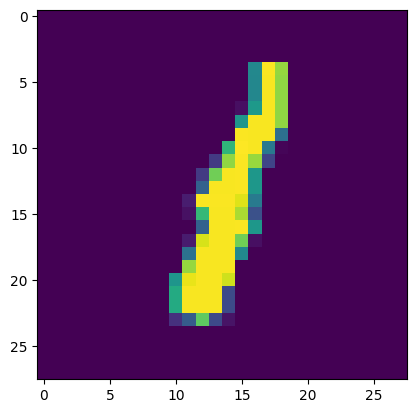

1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[8.6641267e-06 9.9781191e-01 3.0557450e-04 1.0994473e-04 6.6607504e-04
  1.9115116e-05 8.1007027e-05 5.7801977e-04 4.0937209e-04 1.0132210e-05]]


In [40]:
n=89
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test_org[n,:,:]
X = X.reshape(1, 784)
X = X.astype('float32')
X = X / 255
prediction = loaded_model.predict(X)
print(prediction)

In [41]:
prediction = np.argmax(prediction)
print(prediction)

1


# Распознавание рукописных цифр сверточной нейронной сетью

In [42]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt

In [43]:
# В Keras встроены средства работы с популярными наборами данных
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

In [44]:
print(x_train_org.shape)
print(y_train_org.shape)
print(x_test_org.shape)
print(y_test_org.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [45]:
x_train = x_train_org.astype('float32')
x_train = x_train / 255

x_test = x_test_org.astype('float32')
x_test = x_test / 255

In [46]:
x_train = np.expand_dims(x_train, axis=3)
x_test = np.expand_dims(x_test, axis=3)

In [47]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [48]:
y_train = utils.to_categorical(y_train_org, 10)
y_test = utils.to_categorical(y_test_org, 10)

In [49]:
model = Sequential()
#model.add(BatchNormalization(input_shape=(28, 28, 1)))

model.add(Conv2D(32, kernel_size=(4, 4), padding='same', input_shape=(28, 28, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(4, 4), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(BatchNormalization())
model.add(Conv2D(128, kernel_size=(4, 4), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 432,746 (1.65 MB)

 Trainable params: 432,554 (1.65 MB)

 Non-trainable params: 192 (768.00 B)

None


In [51]:
model.fit(x_train, y_train, batch_size=200, epochs=7,  verbose=1)

Epoch 1/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 154s 504ms/step - accuracy: 0.9110 - loss: 0.2821
Epoch 2/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 201s 499ms/step - accuracy: 0.9771 - loss: 0.0746
Epoch 3/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 201s 495ms/step - accuracy: 0.9840 - loss: 0.0522
Epoch 4/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 204s 502ms/step - accuracy: 0.9862 - loss: 0.0441
Epoch 5/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 152s 506ms/step - accuracy: 0.9884 - loss: 0.0379
Epoch 6/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 199s 497ms/step - accuracy: 0.9895 - loss: 0.0334
Epoch 7/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 148s 493ms/step - accuracy: 0.9905 - loss: 0.0314


In [52]:
# Оцениваем качество обучения сети на тестовых данных
scores = model.evaluate(x_test, y_test, verbose=0)
print("Точность работы на тестовых данных: %.2f%%" % (scores[1]*100))

Точность работы на тестовых данных: 99.24%


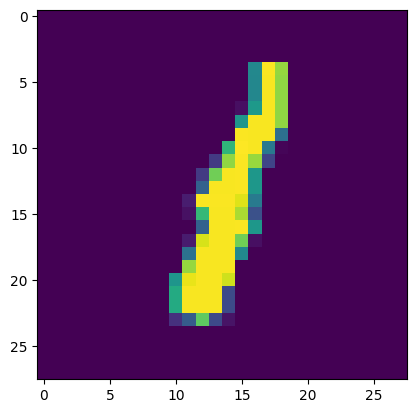

1
(28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
[[6.7915977e-08 9.9998355e-01 1.1452419e-06 2.8801196e-07 3.2598159e-06
  9.8057875e-08 3.8258244e-07 8.7065655e-06 2.1006967e-06 4.0954862e-07]]


In [53]:
n=89
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test[n,:,:,:]
print(X.shape)
X = np.expand_dims(X, axis=0)
prediction = model.predict(X)
print(prediction)

In [54]:
prediction = np.argmax(prediction)
print(prediction)

1


In [56]:
print("Сохраняем сеть")
# Сохраняем сеть для последующего использования
# Генерируем описание модели в формате json
model_json = model.to_json()
json_file = open("mnist_model_CNN.json", "w")
# Записываем архитектуру сети в файл
json_file.write(model_json)
json_file.close()
# Записываем данные о весах в файл
model.save_weights("mnist_model_CNN.weights.h5")
print("Сохранение сети завершено")

Сохраняем сеть
Сохранение сети завершено


In [58]:
from tensorflow.keras.models import model_from_json

print("Загружаю сеть из файлов")
# Загружаем данные об архитектуре сети
json_file = open("mnist_model_CNN.json", "r")
loaded_model_json = json_file.read()
json_file.close()
# Создаем модель
loaded_model = model_from_json(loaded_model_json)
# Загружаем сохраненные веса в модель
loaded_model.load_weights("mnist_model_CNN.weights.h5")
print("Загрузка сети завершена")

Загружаю сеть из файлов
Загрузка сети завершена


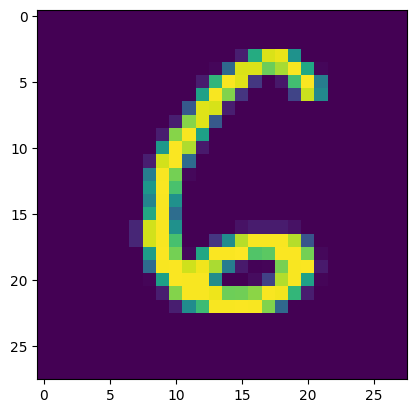

6
(28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
[[2.2427285e-08 3.1423757e-12 2.2793927e-09 7.9562404e-13 2.4722687e-11
  3.1228499e-08 1.0000000e+00 6.2045506e-15 5.1800204e-09 2.9432743e-12]]


In [59]:
n=98
#Вывод тестируемой цифры
img = x_test_org[n,:,:]
plt.imshow(img)
plt.show()
print(y_test_org[n])
#Подготовка данных для подачи на сеть
X = x_test[n,:,:,:]
print(X.shape)
X = np.expand_dims(X, axis=0)
prediction = loaded_model.predict(X)
print(prediction)

In [60]:
prediction = np.argmax(prediction)
print(prediction)

6


# Тестирование собственного изображения

(100, 100, 3)


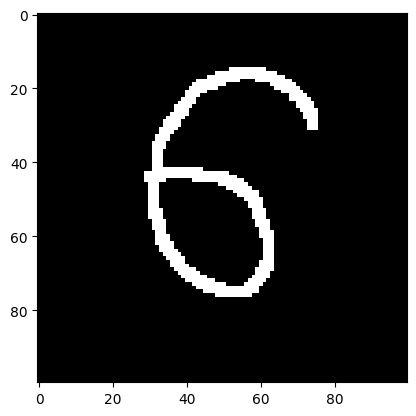

(100, 100)


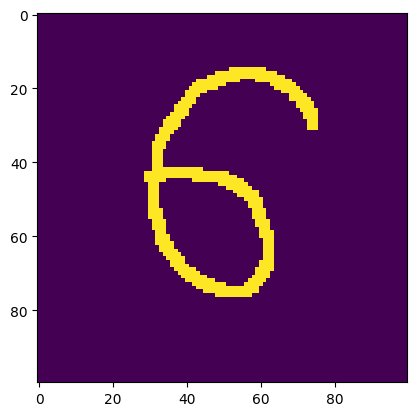

In [63]:
import cv2

#Загружаем изображение
image = cv2.imread('/content/gdrive/MyDrive/my_5.png')
print(image.shape)
plt.imshow(image)
plt.show()
#Загружаем изображение в оттенках серого
image = cv2.imread('/content/gdrive/MyDrive/my_5.png', cv2.IMREAD_GRAYSCALE)
print(image.shape)
#Отображение файла встроенными средствами OpenCV.
plt.imshow(image)
plt.show()

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [65]:
dim=(28,28)
resized = cv2.resize(image, dim, interpolation = cv2.INTER_AREA)
print(resized.shape)

(28, 28)


In [66]:
resized = np.expand_dims(resized, axis=0)
resized = np.expand_dims(resized, axis=3)
print(resized.shape)

(1, 28, 28, 1)


In [67]:
prediction = loaded_model.predict(resized)
print(prediction)
prediction = np.argmax(prediction)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
[[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
  3.8513646e-21 1.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]]
6


**Выводы:** В ходе выполнения практической работы были изучены методы создания и обучения нейронных сетей для распознавания цифр, изображенных на картинках.

В процессе работы были выполнены загрузка и предварительная обработка данных, нормализация изображений, создание последовательной модели, создание и обучение моделей нейронных сетей.

После обучения была проведена проверка точности работы моделей на тестовых данных и выполнено распознавание отдельных изображений цифр.